In [4]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt


In [5]:
train=pd.read_csv("./data/preprocessedTrain.csv")
test=pd.read_csv("./data/preprocessedTest.csv")

# To fill nulls for CNN
print(train.isnull().sum())
train['f_Header_b_payload_Ratio'] = train['f_Header_b_payload_Ratio'].replace(np.nan, train['f_Header_b_payload_Ratio'].max() + 1) 
train['b_Header_f_payload_Ratio'] = train['b_Header_f_payload_Ratio'].replace(np.nan, train['b_Header_f_payload_Ratio'].max() + 1) 
print(train.isnull().sum())

test['f_Header_b_payload_Ratio'] = test['f_Header_b_payload_Ratio'].replace(np.nan, test['f_Header_b_payload_Ratio'].max() + 1) 
test['b_Header_f_payload_Ratio'] = test['b_Header_f_payload_Ratio'].replace(np.nan, test['b_Header_f_payload_Ratio'].max() + 1) 

id.orig_p                       0
id.resp_p                       0
service                         0
flow_duration                   0
fwd_pkts_tot                    0
                            ...  
f_Header_b_payload_Ratio    84484
b_Header_f_payload_Ratio     5446
bwd_payload_zero_flg            0
fwd_payload_zero_flg            0
attack_type                     0
Length: 83, dtype: int64
id.orig_p                   0
id.resp_p                   0
service                     0
flow_duration               0
fwd_pkts_tot                0
                           ..
f_Header_b_payload_Ratio    0
b_Header_f_payload_Ratio    0
bwd_payload_zero_flg        0
fwd_payload_zero_flg        0
attack_type                 0
Length: 83, dtype: int64


In [6]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train class counts:\n", train["attack_type"].value_counts())
print("Test class counts:\n", test["attack_type"].value_counts())


Train shape: (98493, 83)
Test shape: (24624, 83)
Train class counts:
 attack_type
2     75727
10     6486
0      6200
3      3317
8      2072
9      1608
6      1600
7       802
1       427
11      202
4        30
5        22
Name: count, dtype: int64
Test class counts:
 attack_type
2     18932
10     1622
0      1550
3       829
8       518
9       402
6       400
7       200
1       107
11       51
4         7
5         6
Name: count, dtype: int64


In [7]:
# train = pd.read_csv("./data/preprocessedTrain.csv")
# test = pd.read_csv("./data/preprocessedTest.csv")

# train = train.fillna(0)
# test = test.fillna(0)

In [8]:
def to_binary_label(y):
# 0 = benign, 1 = malicious
    return [0 if val in [3, 11, 12] else 1 for val in y]




y_train = to_binary_label(train["attack_type"].values)
y_test = to_binary_label(test["attack_type"].values)




X_train = train.drop("attack_type", axis=1).values
X_test = test.drop("attack_type", axis=1).values

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

In [10]:
X_train_tensor = torch.tensor(X_train_res, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_res, dtype=torch.float32).view(-1, 1)




X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [11]:
def pad_to_square(X, size=90):
    pad_len = size - X.shape[1]
    if pad_len > 0:
        X = F.pad(X, (0, pad_len))
        return X




X_train_padded = pad_to_square(X_train_tensor)
X_test_padded = pad_to_square(X_test_tensor)

In [12]:
X_train_cnn = X_train_padded.view(-1, 1, 9, 10)
X_test_cnn = X_test_padded.view(-1, 1, 9, 10)




train_dataset = TensorDataset(X_train_cnn, y_train_tensor)
test_dataset = TensorDataset(X_test_cnn, y_test_tensor)




train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [13]:



class BinaryAttackCNN(nn.Module):
    def __init__(self):
        super(BinaryAttackCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)
        self.flatten_dim = 32 * 4 * 5 # after pooling
        self.fc1 = nn.Linear(self.flatten_dim, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, self.flatten_dim)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x


model = BinaryAttackCNN()
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [14]:
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/10], Loss: 0.0585
Epoch [2/10], Loss: 0.0135
Epoch [3/10], Loss: 0.0078
Epoch [4/10], Loss: 0.0051
Epoch [5/10], Loss: 0.0037
Epoch [6/10], Loss: 0.0034
Epoch [7/10], Loss: 0.0028
Epoch [8/10], Loss: 0.0024
Epoch [9/10], Loss: 0.0021
Epoch [10/10], Loss: 0.0019


In [15]:
# #model
# class BinaryAttackClassifier(nn.Module):
#     def __init__(self, input_size=83, hidden_size=128):
#         super(BinaryAttackClassifier, self).__init__()
#         self.fc1 = nn.Linear(input_size, hidden_size)
#         self.fc2 = nn.Linear(hidden_size, hidden_size)
#         self.fc3 = nn.Linear(hidden_size, 1)  # raw logits

#     def forward(self, x):
#         x = F.relu(self.fc1(x))
#         x = F.relu(self.fc2(x))
#         x = self.fc3(x)  # raw logits
#         return x

# model = BinaryAttackClassifier(input_size=X_train.shape[1])
# criterion = nn.BCEWithLogitsLoss()  # handles logits internally
# optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)


In [16]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        preds = (torch.sigmoid(outputs) > 0.5).int()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=["Benign", "Malicious"]))


[[  873     7]
 [   15 23729]]
              precision    recall  f1-score   support

      Benign       0.98      0.99      0.99       880
   Malicious       1.00      1.00      1.00     23744

    accuracy                           1.00     24624
   macro avg       0.99      1.00      0.99     24624
weighted avg       1.00      1.00      1.00     24624



In [17]:
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)




print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Benign", "Malicious"]))
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")


Classification Report:
              precision    recall  f1-score   support

      Benign       0.98      0.99      0.99       880
   Malicious       1.00      1.00      1.00     23744

    accuracy                           1.00     24624
   macro avg       0.99      1.00      0.99     24624
weighted avg       1.00      1.00      1.00     24624

Accuracy: 0.9991
Precision: 0.9997
Recall: 0.9994
F1 Score: 0.9995


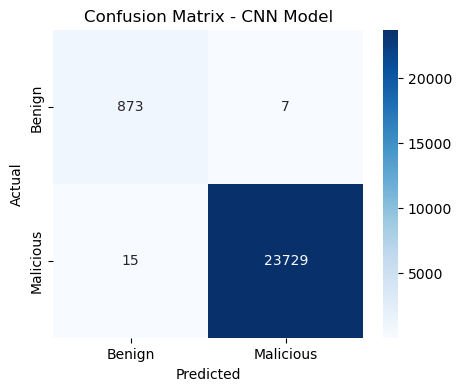

In [18]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Benign", "Malicious"], yticklabels=["Benign", "Malicious"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - CNN Model")
plt.show()

In [19]:
# model = BinaryAttackClassifier(input_size=X_train_tensor.shape[1])
# criterion = nn.BCEWithLogitsLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# # Split mini-validation set from training
# X_train_sub, X_val, y_train_sub, y_val = train_test_split(
#     X_train_tensor, y_train_tensor, test_size=0.1, random_state=42
# )
# train_loader = DataLoader(TensorDataset(X_train_sub, y_train_sub), batch_size=64, shuffle=True)
# val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=64)

# #training
# epochs = 20
# for epoch in range(epochs):
#     model.train()
#     running_loss = 0.0
#     for inputs, labels in train_loader:
#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()
#         running_loss += loss.item()

#     # Mini-validation
#     model.eval()
#     val_loss = 0.0
#     correct = 0
#     total = 0
#     with torch.no_grad():
#         for inputs, labels in val_loader:
#             outputs = model(inputs)
#             loss_val = criterion(outputs, labels)
#             val_loss += loss_val.item()
#             predicted = (torch.sigmoid(outputs) > 0.5).float()
#             correct += (predicted == labels).sum().item()
#             total += labels.size(0)

#     val_acc = correct / total
#     print(f"Epoch [{epoch+1}/{epochs}], "
#           f"Train Loss: {running_loss/len(train_loader):.4f}, "
#           f"Val Loss: {val_loss/len(val_loader):.4f}, "
#           f"Val Acc: {val_acc*100:.2f}%")


In [20]:
# from sklearn.metrics import classification_report

# all_labels = []
# all_preds = []

# model.eval()
# with torch.no_grad():
#     for inputs, labels in test_loader:
#         outputs = model(inputs)
#         preds = (outputs > 0.5).float()
#         all_labels.extend(labels.cpu().numpy())
#         all_preds.extend(preds.cpu().numpy())

# print(classification_report(all_labels, all_preds, target_names=['Benign', 'Attack']))
